# Telescope Data Classification using K-Nearest Neighbors (KNN)

## Overview
This project applies the **K-Nearest Neighbors (KNN)** algorithm to the **Telescope Dataset** using two different approaches:
1. A **manual KNN implementation** (built from scratch)
2. A **Scikit-learn KNN implementation**

The comparison process involves:
1. Evaluating **validation accuracy** using 15% of the data as a validation set  
2. **Visualizing accuracy variation** with respect to different values of `k`  
3. Determining the **optimal k** and applying it to the test set (also 15% of the data)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


import classification_telescopedata
import classification_telescopedata_sklearn
import load_data_file

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score

### Step 1: Data Loading and Preprocessing
- Handled by `load_data_file.py`.
- Loads the dataset from `telescope_data.csv`.
- Randomly excludes some data from class **‘g’** to balance both classes (‘g’ and ‘h’).
- Normalizes feature values so all attributes contribute equally.
- Splits the dataset into **training**, **validation**, and **testing** subsets.

In [3]:
if __name__ == "__main__":
    #function for data loading and preprocessing
    X_train, y_train, X_validation, y_validation, X_test, y_test= load_data_file.load_data()

### Step 2: Find best k for both implementations
a) **Manual KNN Implementation**
- Implemented in `classification_telescopedata.py`.
- Uses **Euclidean distance** and **majority voting** to predict labels.
- Determines the **best k** value based on validation accuracy.

b) **Scikit-learn KNN Implementation**
- Implemented in `classification_telescopedata_sklearn.py`.
- Uses `KNeighborsClassifier` from `sklearn.neighbors`.
- The function `validation_accuracy_sklearn()` identifies the optimal `k` value.

In [4]:
#finds best K using validation set for sklearn implementation
best_k_sklearn, best_acc_sklearn, k_values_sklearn, accuracies_sklearn = classification_telescopedata_sklearn.validation_accuracy_sklearn(X_train, y_train, X_validation, y_validation)
#finds best K using validation set for manual implementation
best_k_manual, best_acc_manual, k_values_manual, accuracies_manual = classification_telescopedata.validation_accuracy_manual(X_train, y_train, X_validation, y_validation)

Testing k=1
New best k: 1, New best accuracy for validation set: 0.8020989505247377
Testing k=3
New best k: 3, New best accuracy for validation set: 0.8070964517741129
Testing k=5
New best k: 5, New best accuracy for validation set: 0.8145927036481759
Testing k=7
New best k: 7, New best accuracy for validation set: 0.8160919540229885
Testing k=9
Testing k=11
Testing k=13
Testing k=15
New best k: 15, New best accuracy for validation set: 0.8215892053973014
Testing k=17
Testing k=19
Testing k=21
Testing k=23
Testing k=25
Testing k=27
Testing k=29
Testing k=31
Testing k=33
Testing k=35
Testing k=37
Testing k=39
Testing k=41
Testing k=43
Testing k=45
Testing k=47
Testing k=49
Testing k=51
Testing k=53
Testing k=55
Testing k=57
Testing k=59
Testing k=61
Testing k=63
Testing k=65
Testing k=67
Testing k=69
Testing k=71
Testing k=73
Testing k=75
Testing k=77
Testing k=79
Testing k=81
Testing k=83
Testing k=85
Testing k=87
Testing k=89
Testing k=91
Testing k=93
Finished testing SKlearn KNN.

Be

### Step 3: Sklearn KNN Implementation
We use the best `k` found earlier to train a KNN classifier using SK Learn with Euclidean distance (`p=2`).

In [5]:
#evaluates best K on test set for sklearn implementation
classifier = KNeighborsClassifier(n_neighbors=best_k_sklearn, p=2, metric='euclidean')
classifier.fit(X_train, y_train)
y_predicted_sklearn = classifier.predict(X_test)

### Step 3b:
Below we print the test accuracy, F1-score, precision, recall, and confusion matrix.

In [6]:
#prints results for sklearn implementation
print("Using SKlearn KNN Classifier:\n")
print("Best k (Sklearn):", best_k_sklearn)
print("Test accuracy with best k:", accuracy_score(y_test, y_predicted_sklearn))
print("F1-score:" , f1_score(y_test, y_predicted_sklearn, average='macro'))
print("Precision:", precision_score(y_test, y_predicted_sklearn, average='macro'))
print("Recall:", recall_score(y_test, y_predicted_sklearn, average='macro'))
print("Confusion matrix:\n", confusion_matrix(y_test, y_predicted_sklearn))

Using SKlearn KNN Classifier:

Best k (Sklearn): 15
Test accuracy with best k: 0.8056801195814649
F1-score: 0.8047162693779303
Precision: 0.8132638407900376
Recall: 0.8063330486424216
Confusion matrix:
 [[879 116]
 [274 738]]


### Step 4: Manual KNN Implementation
We now test our manually implemented KNN classifier using the same best `k` value.

In [7]:
#evaluates best K on test set for manual implementation
best_model = classification_telescopedata.KNN(k=best_k_manual)
best_model.fit(X_train, y_train)
y_predicted_manual = best_model.predict(X_test)

### Step 4b: 
We calculate accuracy, precision, recall, F1-score, and confusion matrix manually.

In [10]:
 #prints results for manual implementation using calculated metrics
TP = np.sum((y_predicted_manual == 'g') & (y_test == 'g'))
TN = np.sum((y_predicted_manual == 'h') & (y_test == 'h'))
FP = np.sum((y_predicted_manual == 'g') & (y_test == 'h'))
FN = np.sum((y_predicted_manual == 'h') & (y_test == 'g'))
precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_manual = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) if (precision_manual + recall_manual) > 0 else 0

#prints results for manual implementation
print("\nUsing the manual KNN Classifier:\n")
print("Best k (Manual):", best_k_manual)
print(f"Test Accuracy with best k:", np.sum(y_predicted_manual == y_test) / len(y_test))
print("F1 Score:", f1_manual)
print("Precision:", precision_manual)
print("Recall:", recall_manual)
print("Confusion Matrix:\n", np.array([[TP, FN],[FP, TN]]), "\n")



Using the manual KNN Classifier:

Best k (Manual): 15
Test Accuracy with best k: 0.8056801195814649
F1 Score: 0.8184357541899442
Precision: 0.7623590633130962
Recall: 0.8834170854271357
Confusion Matrix:
 [[879 116]
 [274 738]] 



### Step 5: Visualization
The plot below shows how validation accuracy changes with different `k` values for both implementations.
![Validation Accuracy vs k](images/accuracy_plot.png)

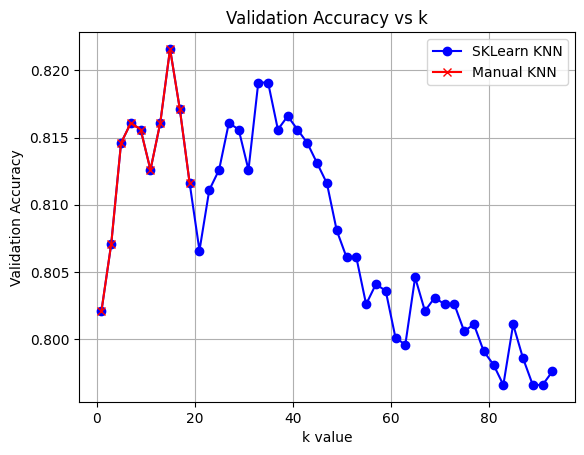

In [9]:
# Plotting accuracy vs k for sklearn implementation
plt.ion() 
plt.plot(k_values_sklearn, accuracies_sklearn, marker='o', color='blue', label='SKLearn KNN')
plt.plot(k_values_manual, accuracies_manual, marker='x', color='red', label='Manual KNN')
plt.xlabel('k value')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs k')
plt.grid(True)
plt.legend()   # <-- this shows which color is which
plt.show()


### Step 6: Evaluation of best k
In KNN, the complexity of the model is controlled by the number of neighbors:

-Small k: The model performs well on training data but not on test data, meaning that the model is too shallow and can be easily influenced and sensitive to noise leading to **overfitting**
-Moderate k: leads to good outcomes in both validation and test sets 
-Large k: model here might lead to **underfitting** where it fails to capture important details in the data.

Here, the best k obtained is **k=15**. The model performs well on both, the validation and test sets.

In our dataset, √n ≈ 95, but this value led to **lower validation accuracy** during experimentation.
A very large k makes the model **too general** — it averages over many points from both classes, which causes **underfitting**.
